<a href="https://colab.research.google.com/github/LsYoli/fisica_computacional/blob/main/Taller_3/cuaderno_Taller3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!which gfortran || (apt-get update -qq && apt-get install -y gfortran)
!gfortran --version | head -n 1

/usr/bin/gfortran
GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0


In [24]:
from google.colab import files

archivos_cargados = files.upload()
print("Archivos cargados:", list(archivos_cargados))

Saving 100_mediciones_pendulo_minimos_cuadrados.xlsx to 100_mediciones_pendulo_minimos_cuadrados.xlsx
Archivos cargados: ['100_mediciones_pendulo_minimos_cuadrados.xlsx']


# Taller de la semana — Determinación de $g$ con un péndulo

## Propósito

Construir un flujo reproducible que empiece con 100 registros experimentales en Excel, documente la limpieza y termine con un ajuste lineal programado en Fortran 2008.

## Parte A. Limpieza de datos

1. Abra `100_mediciones_pendulo_minimos_cuadrados.xlsx` y revise la hoja `Datos_estudiantes`.
2. Ejecute el script de limpieza suministrado por el profesor.
3. Complete sus tres tareas: correcciones justificadas, elección del ángulo máximo y exclusiones manuales.
4. No excluya un dato únicamente porque se aleja de la tendencia. Toda corrección o exclusión debe apoyarse en la información experimental.
5. El script debe generar `pendulo_limpio.dat` e `informe_limpieza.xlsx`.


In [25]:
"""Limpieza de mediciones de un péndulo y exportación para Fortran.

Por favor complete los tres bloques marcados como TODO.
"""

from pathlib import Path

import pandas as pd


# ============================================================
# 1. LECTURA DEL ARCHIVO
# ============================================================

ARCHIVO_ENTRADA = Path("100_mediciones_pendulo_minimos_cuadrados.xlsx")
HOJA = "Datos_estudiantes"

if not ARCHIVO_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {ARCHIVO_ENTRADA}. "
        "Guarde el script y el archivo de Excel en la misma carpeta."
    )

datos = pd.read_excel(ARCHIVO_ENTRADA, sheet_name=HOJA)

columnas_requeridas = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
    "observacion_campo",
    "calidad_video",
]

columnas_ausentes = [
    columna for columna in columnas_requeridas if columna not in datos.columns
]

if columnas_ausentes:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo: "
        + ", ".join(columnas_ausentes)
    )

# Se conserva una copia independiente de los datos originales.
datos_originales = datos.copy(deep=True)

print("\nNúmero inicial de registros:", len(datos))
print("\nPrimeras mediciones:")
print(datos.head())


# ============================================================
# 2. COLUMNAS PARA DOCUMENTAR LA LIMPIEZA
# ============================================================

datos["incluir"] = True
datos["accion_limpieza"] = "Conservar"
datos["justificacion"] = "Medición aceptada"


def excluir_registros(condicion, justificacion):
    """Excluye únicamente registros que todavía estaban aceptados."""
    nuevos = condicion.fillna(False) & datos["incluir"]
    datos.loc[nuevos, "incluir"] = False
    datos.loc[nuevos, "accion_limpieza"] = "Excluir"
    datos.loc[nuevos, "justificacion"] = justificacion


# ============================================================
# 3. CORRECCIONES JUSTIFICADAS
# ============================================================

# TODO 1:
# Complete los diccionarios con las correcciones que considere
# justificadas. La forma es:
#
# medicion_id: valor_corregido
#
# Si no desea corregir ningún registro, deje el diccionario vacío.

correcciones_longitud = {
    52:70
    # medicion_id: longitud_correcta
    # No corregi ningun registro
}

correcciones_tiempo = {
    23:19.060,
    81:18.530
    ## se cambiaron estos valores porque en la observacion
    ## se copiaron los valores de la pantalla del programa,
    ## que seguramente abra dado el periodo (T= n_Osc/tiempo)
}

for medicion_id, valor in correcciones_longitud.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "longitud_cm"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir longitud"
    datos.loc[condicion, "justificacion"] = (
        "Error de registro identificado y corregido"
    )

for medicion_id, valor in correcciones_tiempo.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "tiempo_medido_s"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir tiempo"
    datos.loc[condicion, "justificacion"] = (
        "El valor registrado no correspondía al tiempo total"
    )


# ============================================================
# 4. EXCLUSIONES AUTOMÁTICAS
# ============================================================

excluir_registros(
    datos["tiempo_medido_s"].isna(),
    "No existe un tiempo medido",
)

excluir_registros(
    datos["numero_oscilaciones"].isna()
    | (datos["numero_oscilaciones"] <= 0),
    "Número de oscilaciones ausente o no positivo",
)


# ============================================================
# 5. DOMINIO DE VALIDEZ DEL MODELO
# ============================================================

# TODO 2:
# Escriba el ángulo máximo, en grados, para el cual utilizará
# la aproximación de ángulo pequeño. Sustituya None por un número.

ANGULO_MAXIMO = 10 #se toma este valor porque fue el asignado por el profesor

if ANGULO_MAXIMO is None:
    raise ValueError(
        "Debe completar TODO 2: asigne un valor numérico a "
        "ANGULO_MAXIMO."
    )

excluir_registros(
    datos["angulo_inicial_deg"].isna()
    | (datos["angulo_inicial_deg"].abs() > ANGULO_MAXIMO),
    "Fuera de la aproximación de ángulo pequeño",
)


# ============================================================
# 6. BÚSQUEDA DE REGISTROS DUPLICADOS
# ============================================================

variables_experimentales = [
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
]

# Solo se buscan duplicados entre registros aún aceptados. Así, un
# registro ya rechazado no provoca la exclusión de una medición válida.
duplicados = pd.Series(False, index=datos.index)
indices_aceptados = datos.index[datos["incluir"]]
duplicados.loc[indices_aceptados] = datos.loc[
    indices_aceptados
].duplicated(subset=variables_experimentales, keep="first")

excluir_registros(
    duplicados,
    "Registro experimental duplicado",
)


# ============================================================
# 7. CÁLCULOS PRELIMINARES E INSPECCIÓN
# ============================================================

# El período se calcula después de aplicar las correcciones.
datos["periodo_preliminar_s"] = (
    datos["tiempo_medido_s"] / datos["numero_oscilaciones"]
)

print("\nLongitudes potencialmente sospechosas:")
print(
    datos.loc[
        (datos["longitud_cm"] < 20) | (datos["longitud_cm"] > 100),
        ["medicion_id", "longitud_cm", "observacion_campo"],
    ]
)

print("\nPeríodos potencialmente sospechosos:")
print(
    datos.loc[
        (datos["periodo_preliminar_s"] < 0.5)
        | (datos["periodo_preliminar_s"] > 3.0),
        [
            "medicion_id",
            "longitud_cm",
            "numero_oscilaciones",
            "tiempo_medido_s",
            "periodo_preliminar_s",
            "observacion_campo",
        ],
    ]
)

print("\nMediciones con calidad de video baja:")
print(
    datos.loc[
        datos["calidad_video"].eq("Baja"),
        ["medicion_id", "calidad_video", "observacion_campo"],
    ]
)


# ============================================================
# 8. EXCLUSIONES QUE REQUIEREN INTERPRETACIÓN
# ============================================================

# TODO 3:
# Agregue las mediciones que deben excluirse por razones
# experimentales que no fueron tratadas automáticamente:
#
# medicion_id: "justificación"

exclusiones_manuales = {
    # medicion_id: "razón de la exclusión"
    12: "no se tomó el tiempo",
    36: "El tiempo medido es desconfiable",
    45: "El tiempo medido no es confiable",
    60: "Registro duplicado",
    68: "No se registro el tiempo",
    77: "El tiempo no es confiable",
    88: "Incertidumbre frente al numero de oscilaciones"
}

for medicion_id, razon in exclusiones_manuales.items():
    condicion = datos["medicion_id"] == medicion_id

    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue

    datos.loc[condicion, "incluir"] = False
    datos.loc[condicion, "accion_limpieza"] = "Excluir"
    datos.loc[condicion, "justificacion"] = razon


# ============================================================
# 9. CONSTRUCCIÓN DEL CONJUNTO LIMPIO
# ============================================================

datos_limpios = datos.loc[datos["incluir"]].copy()

print("\nNúmero de registros originales:", len(datos_originales))
print("Número de registros aceptados:", len(datos_limpios))
print("Número de registros excluidos:", len(datos) - len(datos_limpios))


# ============================================================
# 10. ARCHIVO PARA FORTRAN
# ============================================================

columnas_fortran = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
]

datos_limpios[columnas_fortran].to_csv(
    "pendulo_limpio.dat",
    sep=" ",
    index=False,
    header=False,
    float_format="%.6f",
)


# ============================================================
# 11. INFORME DE LIMPIEZA
# ============================================================

columnas_informe = [
    "medicion_id",
    "incluir",
    "accion_limpieza",
    "justificacion",
]

datos[columnas_informe].to_excel(
    "informe_limpieza.xlsx",
    index=False,
)

print("\nArchivos generados:")
print("  pendulo_limpio.dat")
print("  informe_limpieza.xlsx")


Número inicial de registros: 100

Primeras mediciones:
   medicion_id  longitud_cm  angulo_inicial_deg  numero_oscilaciones  \
0            1           55                   8                   10   
1            2           90                   5                   10   
2            3           40                   8                   10   
3            4           75                   5                   10   
4            5           25                   8                   10   

   tiempo_medido_s observador calidad_video observacion_campo  
0           14.975        Ana          Alta               NaN  
1           19.135       Luis          Alta               NaN  
2           12.629      María          Alta               NaN  
3           17.416      Jorge          Alta               NaN  
4            9.934        Ana          Alta               NaN  

Longitudes potencialmente sospechosas:
Empty DataFrame
Columns: [medicion_id, longitud_cm, observacion_campo]
Index: []

Perío

## Parte B. Programa en Fortran 2008

Realice el diagrama de flujo respectivo y escriba el programa `ajuste_pendulo.f90`. El programa debe:

1. Abrir `pendulo_limpio.dat` y comprobar que el archivo se abrió correctamente.
2. Leer un número desconocido de filas mediante un ciclo y `iostat`.
3. Convertir cada longitud de centímetros a metros.
4. Calcular $T$ y construir $x=L$ y $y=T^2$.
5. Acumular $N$, $s_x$, $s_y$, $s_{xx}$ y $s_{xy}$.
6. Calcular la pendiente $a$ y el intercepto $b$.
7. Estimar $g=4\pi^2/a$.
8. Realizar una segunda lectura del archivo para calcular $R^2$.
9. Mostrar claramente $N$, $a$, $b$, $R^2$ y $g$, incluyendo unidades.
10. Escribir esos cinco valores, en ese orden y sin encabezado, en `resultados_ajuste.dat`.
11. Detectar al menos estos errores: archivo inexistente, menos de dos datos y denominador nulo.

Para estandarizar el archivo que revisará la celda PASS/FAIL, declare una unidad de salida entera y use al final del programa:

```fortran
open(newunit=unidad_salida, file='resultados_ajuste.dat', &
     status='replace', action='write')
write(unidad_salida, *) n, a, b, r2, g
close(unidad_salida)
```

Compile con advertencias y comprobaciones activadas:

```bash
gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
./ajuste_pendulo
```

In [33]:
%%writefile ajuste_pendulo.f90
program ajuste_pendulo
  use iso_fortran_env, only: real64, iostat_end                               !Precision y fin del archivo
  implicit none                                                               !Evita variables implícitas

  integer :: unidad, unidad_salida, estado, id, n, n_osc                      !Control del archivo y contador
  real(real64) :: longitud_cm, angulo_deg, tiempo_s, periodo_s                !Datos leídos del archivo
  real(real64) :: x, y, y_media, y_ajustada                                   !Variables del ajuste: x = L, y = T^2
  real(real64) :: sx, sy, sxx, sxy, den, a, b, r2, g, ss_res, ss_tot          !Sumas y parámetros
  real(real64), parameter :: pi = 3.14159265358979323846264338327950288_real64  !constante pi
  real(real64), parameter :: tol = 1.0e-12_real64                             !Tolerancia para detectar valores nulos

  ! Lectura del archivo
  open(newunit=unidad, file='pendulo_limpio.dat', status='old', &
       action='read', iostat=estado)
  if (estado /= 0) then                                                       !el archivo no existe o no se pudo abrir
    print *, 'ERROR: no se pudo abrir pendulo_limpio.dat (iostat =', estado, ')'
    stop 1
  end if
  print *, 'Archivo pendulo_limpio.dat abierto correctamente.'

  ! Inicializa el contador y los acumuladores antes de leer
  n   = 0
  sx  = 0.0_real64
  sy  = 0.0_real64
  sxx = 0.0_real64
  sxy = 0.0_real64

  do
    read(unidad, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s

    if (estado == iostat_end) exit                                            !fin normal del archivo
    if (estado /= 0) then                                                     !fila con formato incorrecto
      print *, 'ERROR: fila ilegible en la lectura (iostat =', estado, ')'
      close(unidad)
      stop 2
    end if
    if (n_osc <= 0) then                                                      !evita dividir entre cero
      print *, 'ERROR: numero de oscilaciones no valido en la medicion', id
      close(unidad)
      stop 2
    end if

    x = longitud_cm / 100.0_real64                                            ! longitud en metros
    periodo_s = tiempo_s / real(n_osc, real64)                                ! Período de una oscilación
    y = periodo_s*periodo_s                                                   ! Período al cuadrado
    n = n + 1                                                                 ! Cuenta la fila aceptada

    sx  = sx  + x                                 ! Acumula longitud_m
    sy  = sy  + y                                 ! Acumula periodo_s^2
    sxx = sxx + x*x                               ! Acumula longitud_m^2
    sxy = sxy + x*y                               ! Acumula longitud_m*periodo_s^2
  end do

  ! Validaciones: menos de dos datos y denominador nulo
  if (n < 2) then
    print *, 'ERROR: se necesitan al menos 2 datos; se leyeron', n
    close(unidad)
    stop 3
  end if

  den = real(n, real64)*sxx - sx*sx
  if (abs(den) < tol) then
    print *, 'ERROR: denominador nulo (todas las longitudes son iguales)'
    close(unidad)
    stop 4
  end if

  ! Usa las sumas para calcular la recta  T^2 = a*L + b  (a pendiente, b intercepto)
  a = (real(n, real64)*sxy - sx*sy) / den
  b = (sy - a*sx) / real(n, real64)

  ! T = 2*pi*sqrt(L/g)  ->  T^2 = (4*pi^2/g)*L  ->  a = 4*pi^2/g
  if (abs(a) < tol) then
    print *, 'ERROR: pendiente nula, no se puede estimar g'
    close(unidad)
    stop 5
  end if
  g = 4.0_real64*pi**2 / a

  ! Segunda lectura del archivo para calcular R^2 (correlación)
  ! R^2 = 1 - SSres/SStot
  rewind(unidad)                                                              !vuelve al inicio del archivo
  y_media = sy / real(n, real64)                                              !promedio de T^2
  ss_res = 0.0_real64                                                         !suma de residuos al cuadrado
  ss_tot = 0.0_real64                                                         !variación total de T^2
  do
    read(unidad, *, iostat=estado) id, longitud_cm, angulo_deg, n_osc, tiempo_s
    if (estado /= 0) exit                                                     !fin del archivo
    x = longitud_cm / 100.0_real64
    periodo_s = tiempo_s / real(n_osc, real64)
    y = periodo_s*periodo_s
    y_ajustada = a*x + b                                                      !T^2 según la recta
    ss_res = ss_res + (y - y_ajustada)**2
    ss_tot = ss_tot + (y - y_media)**2
  end do
  close(unidad)

  if (ss_tot < tol) then
    print *, 'ERROR: T^2 no varia; R^2 no esta definido'
    stop 6
  end if
  r2 = 1.0_real64 - ss_res/ss_tot

  print '(A,I0)',          ' N  = ', n
  print '(A,F12.8,A)',    ' a  = ', a,  ' s^2/m   (pendiente)'
  print '(A,F12.8,A)',    ' b  = ', b,  ' s^2     (intercepto)'
  print '(A,F12.8,A)',     ' R2 = ', r2, '         (calidad del ajuste)'
  print '(A,F12.6,A)',     ' g  = ', g,  ' m/s^2'


  open(newunit=unidad_salida, file='resultados_ajuste.dat', &
       status='replace', action='write')
  write(unidad_salida, *) n, a, b, r2, g
  close(unidad_salida)

end program ajuste_pendulo


Overwriting ajuste_pendulo.f90


In [27]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90
!./ajuste_pendulo

 Archivo pendulo_limpio.dat abierto correctamente.
 N  = 89
 a  =   4.04873469 s^2/m   (pendiente)
 b  =  -0.00288786 s^2     (intercepto)
 R2 =   0.99974782         (calidad del ajuste)
 g  =     9.750804 m/s^2


## Parte C. Visualización en Python

Complete la celda para representar $T^2$ en función de $L$, la recta calculada con Fortran y los residuos. No use Python para volver a realizar el ajuste: los valores de `a` y `b` deben proceder de su programa Fortran.

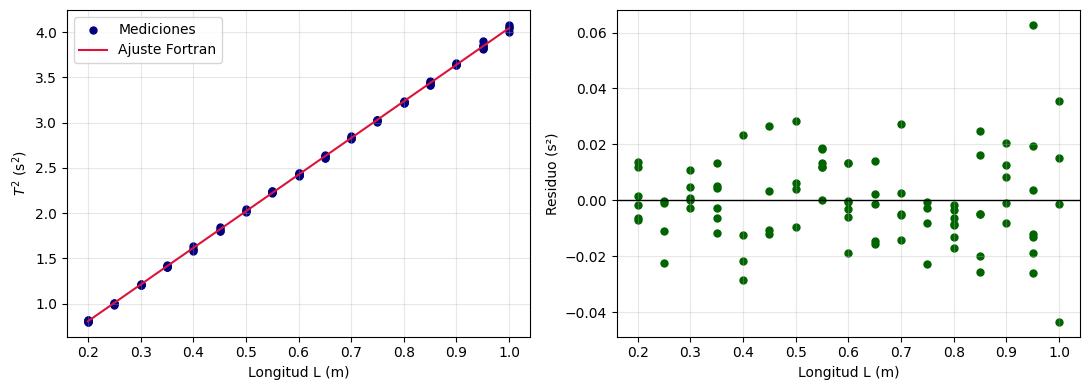

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# TODO: construya las variables linealizadas x=L y y=T^2
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Copie los parámetros calculados por su programa Fortran
a = 4.04873469
b = -0.00288786

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden], color="crimson", label="Ajuste Fortran")
ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")
ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()
# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png", dpi=200, bbox_inches="tight")
plt.show()

## Verificación final PASS/FAIL

Para agilizar la revisión, la tarea debe cerrar ejecutando esta celda. La verificación calcula valores de referencia directamente a partir de `pendulo_limpio.dat` y los compara con `resultados_ajuste.dat`. También comprueba que se haya generado la figura.

Un `PASS` indica que el resultado supera esa comprobación automática; no sustituye la revisión de la limpieza, la estructura del programa, las unidades ni la interpretación física.

In [32]:
from pathlib import Path
import numpy as np

# Función auxiliar que imprime un veredicto uniforme para cada prueba
resultados_pruebas = []

def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    print(f"{estado:<4}  {nombre}{detalle}")
    resultados_pruebas.append(bool(condicion))
    return bool(condicion)

# Archivos que debe producir el flujo de trabajo completo
archivo_datos = Path("pendulo_limpio.dat")
archivo_resultados = Path("resultados_ajuste.dat")
archivo_figura = Path("ajuste_pendulo_y_residuos.png")

# Primer nivel: comprueba existencia antes de intentar leer
ok_datos = informar("Existe pendulo_limpio.dat", archivo_datos.exists())
ok_resultados = informar("Existe resultados_ajuste.dat", archivo_resultados.exists())
informar("Existe la figura", archivo_figura.exists() and archivo_figura.stat().st_size > 0 if archivo_figura.exists() else False)

# Segundo nivel: valida formatos y compara con un cálculo independiente
if ok_datos and ok_resultados:
    try:
        datos = np.atleast_2d(np.loadtxt(archivo_datos))
        resultados = np.loadtxt(archivo_resultados).reshape(-1)

        estructura_datos = datos.shape[1] == 5 and datos.shape[0] >= 2
        estructura_resultados = resultados.size == 5
        informar("Formato del archivo de datos", estructura_datos, f"  filas={datos.shape[0]}, columnas={datos.shape[1]}")
        informar("Formato del archivo de resultados", estructura_resultados, f"  valores={resultados.size}")

        if estructura_datos and estructura_resultados:
            # Reconstruye x=L y y=T^2 directamente desde los datos limpios
            longitud_m = datos[:, 1] / 100.0
            periodo_s = datos[:, 4] / datos[:, 3]
            x = longitud_m
            y = periodo_s**2
            n_ref = len(x)

            # Calcula los valores de referencia con las fórmulas del método
            sx = np.sum(x)
            sy = np.sum(y)
            sxx = np.sum(x*x)
            sxy = np.sum(x*y)
            den = n_ref*sxx - sx*sx
            a_ref = (n_ref*sxy - sx*sy) / den
            b_ref = (sy - a_ref*sx) / n_ref
            residuos_ref = y - (a_ref*x + b_ref)
            sse_ref = np.sum(residuos_ref**2)
            sst_ref = np.sum((y - np.mean(y))**2)
            r2_ref = 1.0 - sse_ref/sst_ref
            g_ref = 4.0*np.pi**2/a_ref

            # Compara, con tolerancia, cada resultado entregado por Fortran
            n_f, a_f, b_f, r2_f, g_f = resultados
            informar("Número de datos N", int(round(n_f)) == n_ref, f"  obtenido={n_f:g}, esperado={n_ref}")
            informar("Pendiente a", np.isclose(a_f, a_ref, rtol=1e-6, atol=1e-9), f"  obtenida={a_f:.8g}, esperada={a_ref:.8g}")
            informar("Intercepto b", np.isclose(b_f, b_ref, rtol=1e-6, atol=1e-9), f"  obtenido={b_f:.8g}, esperado={b_ref:.8g}")
            informar("Coeficiente R²", np.isclose(r2_f, r2_ref, rtol=1e-6, atol=1e-9), f"  obtenido={r2_f:.8g}, esperado={r2_ref:.8g}")
            informar("Gravedad g", np.isclose(g_f, g_ref, rtol=1e-6, atol=1e-9), f"  obtenida={g_f:.8g}, esperada={g_ref:.8g}")
            informar("Valor físico razonable de g", 7.0 < g_f < 12.0, f"  g={g_f:.5f} m/s²")
    except Exception as error:
        informar("No fue posible completar la verificación", False, f": {error}")

# Resumen que debe copiarse en el informe de una página
n_pass = sum(resultados_pruebas)
n_total = len(resultados_pruebas)
print(f"\nRESUMEN PASS/FAIL: {n_pass} de {n_total} pruebas pasaron.")

PASS  Existe pendulo_limpio.dat
PASS  Existe resultados_ajuste.dat
PASS  Existe la figura
PASS  Formato del archivo de datos  filas=89, columnas=5
PASS  Formato del archivo de resultados  valores=5
PASS  Número de datos N  obtenido=89, esperado=89
PASS  Pendiente a  obtenida=4.0487347, esperada=4.0487347
PASS  Intercepto b  obtenido=-0.0028878571, esperado=-0.0028878571
PASS  Coeficiente R²  obtenido=0.99974782, esperado=0.99974782
PASS  Gravedad g  obtenida=9.7508038, esperada=9.7508038
PASS  Valor físico razonable de g  g=9.75080 m/s²

RESUMEN PASS/FAIL: 11 de 11 pruebas pasaron.
